# Exploratory Data Analysis (EDA) - Proyecto EEG Signal Analysis

Este notebook orquesta el pipeline completo del proyecto, siguiendo las directrices de modularidad. Se encarga de transformar, limpiar, extraer características (features) y visualizar los datos obtenidos de los dispositivos **Emotiv EPOC** y **Emotive Insight**.

## 1. Configuración e Importación de Módulos
Aseguramos que el entorno reconozca la carpeta `src/` para poder importar nuestras funciones personalizadas.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Añadir el directorio raíz al path para módulos src
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import RAW_PATH, EP_RAW, IN_RAW, CSV_RAWS


## 2. Transformación y Carga de Datos
Convertimos los archivos originales `.txt` a formato `.csv` (limitando a los primeros 5000 registros para facilitar el desarrollo) y los cargamos en un diccionario de DataFrames.

In [10]:
from src.io import txt_transform_csv, load_csv_files

print('Transformando archivos...')
txt_transform_csv(RAW_PATH, EP_RAW, IN_RAW)

print('\nCargando archivos CSV...')
dataframes = load_csv_files(RAW_PATH, CSV_RAWS)


Transformando archivos...
Reading and transforming text files from input...
The file EP.csv already exists. Avoiding transformation.
The file IN.csv already exists. Avoiding transformation.
.csv files names: ['EP.csv', 'IN.csv', 'EP.csv', 'IN.csv']

Cargando archivos CSV...
----------Loaded dataframe EP.csv----------
      id  event device channel  code  size  \
0  67635  67635     EP     AF3     6   260   
1  67636  67635     EP      F7     6   260   
2  67637  67635     EP      F3     6   260   
3  67638  67635     EP     FC5     6   260   
4  67639  67635     EP      T7     6   260   

                                              signal  
0  ['4395.384615', '4382.564102', '4377.435897', ...  
1  ['4489.230769', '4475.384615', '4474.358974', ...  
2  ['4538.461538', '4528.717948', '4524.615384', ...  
3  ['4207.692307', '4205.641025', '4200.512820', ...  
4  ['4497.948717', '4498.461538', '4494.871794', ...  
----------Loaded dataframe IN.csv----------
        id   event device chan

## 3. Limpieza de Datos (Cleaning)
¿Cómo se distribuyen los datos después de la limpieza?

### 3.1. Asegurar consistencia de datos

Aplicamos el módulo `cleaning.py` para:
- Eliminar espacios en blanco y forzar tipos numéricos.
- Transformar la columna `signal` de string a una lista de floats reales.
- Eliminar nulos y duplicados.

In [11]:
from src.cleaning import clean

for file_name, df in dataframes.items():
    dataframes[file_name] = clean(df)

# Unificamos los datos limpios en un único DataFrame para extraer features conjuntamente.
# ignore_index=True evita problemas de índices solapados al concatenar.
df_complete = pd.concat(dataframes.values(), ignore_index=True)
print(f'\nTotal de registros unificados y limpios: {df_complete.shape[0]}')


Duplicated rows: 0
Last value of first registered signal before processing: ]
Last value of first registered signal after processing: 4390.76923
Null values by column:


id         0
event      0
device     0
channel    0
code       0
size       0
signal     0
dtype: int64

----------Cleaned dataset----------
Dataset rows and columns: (5000, 7)
      id  event device channel  code  size  \
0  67635  67635     EP     AF3     6   260   
1  67636  67635     EP      F7     6   260   
2  67637  67635     EP      F3     6   260   
3  67638  67635     EP     FC5     6   260   
4  67639  67635     EP      T7     6   260   

                                              signal  
0  [4395.384615, 4382.564102, 4377.435897, 4387.1...  
1  [4489.230769, 4475.384615, 4474.358974, 4486.6...  
2  [4538.461538, 4528.717948, 4524.615384, 4526.1...  
3  [4207.692307, 4205.641025, 4200.51282, 4194.35...  
4  [4497.948717, 4498.461538, 4494.871794, 4497.9...  
                 id         event         code         size
count   5000.000000   5000.000000  5000.000000  5000.000000
mean   70134.500000  67813.071600     4.376800   259.459600
std     1443.520003    103.108467     2.965229     2.384765
min    67635.000000  67635.000000     0.000000   248.000000
25%    68884.750000  

id         0
event      0
device     0
channel    0
code       0
size       0
signal     0
dtype: int64

----------Cleaned dataset----------
Dataset rows and columns: (5000, 7)
        id   event device channel  code  size  \
0  1142043  173652     IN     AF3     0   256   
1  1142044  173652     IN     AF4     0   256   
2  1142045  173652     IN      T7     0   256   
3  1142046  173652     IN      T8     0   256   
4  1142047  173652     IN      PZ     0   256   

                                              signal  
0  [4259.487179, 4237.948717, 4247.179487, 4242.0...  
1  [4103.076923, 4100.51282, 4102.564102, 4087.69...  
2  [4245.128205, 4218.461538, 4242.051282, 4245.1...  
3  [4208.717948, 4188.717948, 4204.102564, 4198.4...  
4  [4189.230769, 4203.589743, 4188.717948, 4186.6...  
                 id          event         code         size
count  5.000000e+03    5000.000000  5000.000000  5000.000000
mean   1.144542e+06  174151.500000     4.539000   253.906000
std    1.443520e+03     288.703862     2.918935     2.365224
min    1.142043e+06  173652.000000     0.000000   248.00000

## 4. Feature Engineering
¿Qué características nuevas se pueden derivar?

Aplicamos `build_features()`, que genera:
1. **Características Espaciales**: Mapea el canal al `Hemisphere` (Left/Right) y al `Lobe` (Frontal, Temporal, etc.).
2. **Características Temporales**: Media, varianza y potencia absoluta de la señal pico a pico.
3. **Características Frecuenciales**: Potencia espectral en bandas Delta, Theta, Alpha, Beta y Gamma usando el método de Welch.

*Una vez extraida la información necesaria eliminamos la columna raw `signal` para optimizar memoria.*

In [12]:
from src.features import build_features

df_features = build_features(df_complete)
display(df_features.head())


----------Start extracting features from raw EEG data----------
----------Calculating bandwith between frequencies 0.5 and 4----------
----------Calculating bandwith between frequencies 4 and 8----------
----------Calculating bandwith between frequencies 8 and 12----------
----------Calculating bandwith between frequencies 13 and 30----------
----------Calculating bandwith between frequencies 30 and 40----------
----------Finished extracting features from raw EEG data----------
First rows from features dataframe
       id  event device channel  code  size hemisphere      lobe  signal_mean  \
0  67635  67635     EP     AF3     6   260       Left   Frontal  4382.761341   
1  67636  67635     EP      F7     6   260       Left   Frontal  4496.575936   
2  67637  67635     EP      F3     6   260       Left   Frontal  4524.260355   
3  67638  67635     EP     FC5     6   260       Left   Frontal  4212.601577   
4  67639  67635     EP      T7     6   260       Left  Temporal  4499.570019   



,id,event,device,channel,code,size,hemisphere,lobe,signal_mean,signal_variance,signal_power,delta,theta,alpha,beta,gamma
0,67635,67635,EP,AF3,6,260,Left,Frontal,4382.761341,71.132896,39.487179,0.425002,0.104021,0.140275,0.254955,0.084009
1,67636,67635,EP,F7,6,260,Left,Frontal,4496.575936,225.374866,65.641025,0.436048,0.061529,0.097414,0.240202,0.066151
2,67637,67635,EP,F3,6,260,Left,Frontal,4524.260355,60.275512,37.435897,0.518737,0.101321,0.098721,0.229324,0.090129
3,67638,67635,EP,FC5,6,260,Left,Frontal,4212.601577,86.934316,47.692307,0.268974,0.128851,0.101477,0.389798,0.135229
4,67639,67635,EP,T7,6,260,Left,Temporal,4499.570019,52.488966,41.025641,0.482815,0.161273,0.065763,0.193372,0.082537


## 5. Visualizaciones y Resolución de Preguntas de Negocio
Representación gráfica de las caracteríscticas extraidas de nuestros datos.

In [13]:
from src.viz import plot_cortical_insights, plot_stimulus_comparison, avg_powers_comparison
from src.cleaning import remove_electrodes

### 5.1 Activación Cortical
¿Existe activación bilateral o unilateral? ¿Qué lóbulo presenta mayor activación?

*Utilizamos un estimador de mediana para evitar que los outliers de la señal distorsionen la visualización.* 

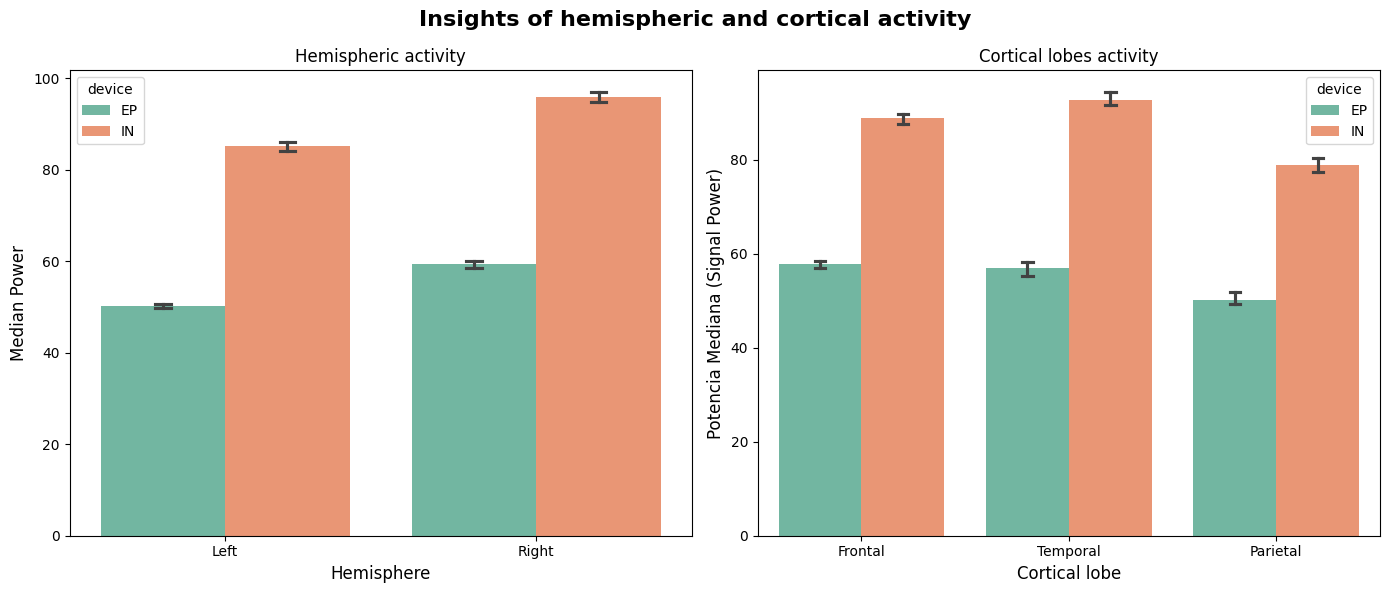

In [14]:
df_hemispheres = remove_electrodes(df_features, 'channel', 'PZ')
df_lobes = remove_electrodes(df_features, 'lobe', 'Occipital')

plot_cortical_insights(df_hemispheres, df_lobes)

#### Actividad hemisférica
Se puede apreciar actividad eléctrica en ambos hemisferios, aunque con ambos dispositivos se detecta una mayor activación del hemisferio derecho.
#### Actividad lobular
De manera similar se detecta una mayor actividad en los lóbulos frontal y temporal en ambos dispositivos, siendo ligeramente más baja la potencia de la señal en el lobulo parietal.


### 5.2 Comparación por Estímulo (Número pensado)
¿Existen diferencias de activación entre los distintos estímulos (visualizar los números del 0 al 9)?

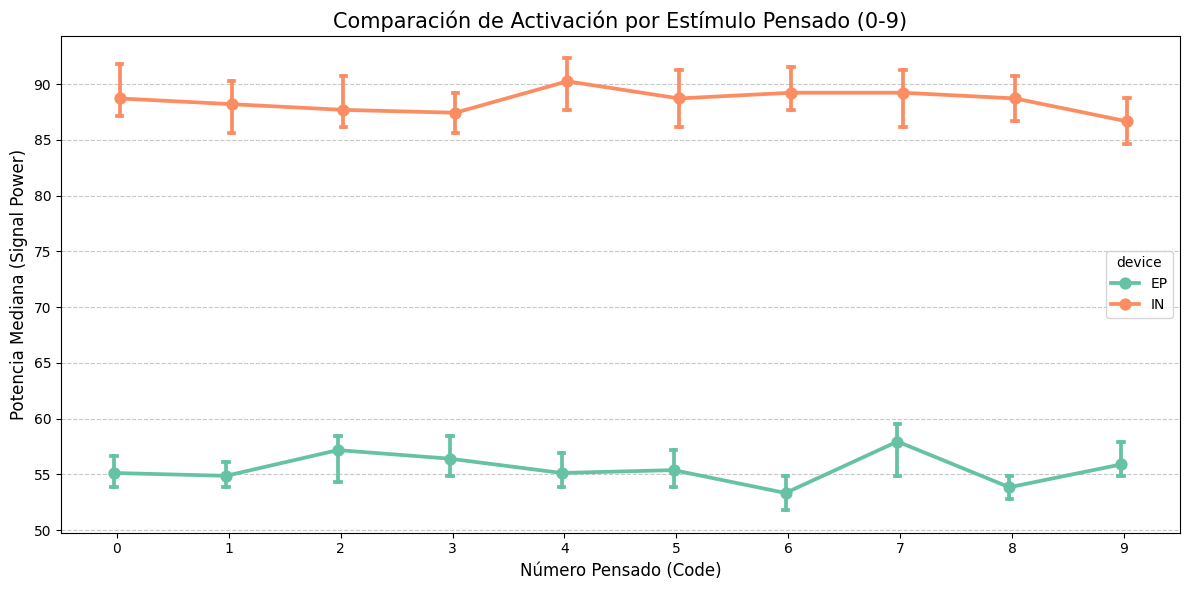

In [15]:
plot_stimulus_comparison(df_features)

#### Potencia absoluta
Observamos que la potencia absoluta medida por la distancia entre picos de voltaje es bastante homogenea entre las señales de los números, 
indicando como era esperable que los procesos neuronales de visualización entre los distintos números es similar sin diferencias significativas.
#### Calidad de señal
Cabe destacar que el dispositivo Insight presenta una mayor amplitud entre picos, lo que suele estar asociado a señales más ruidosas o con oscilaciones mayores. 
Esto podría utilizarse como posible comparador de calidad en el registro de la señal entre ambos dispositivos, siendo a primera vista el dispositivo EPOC el que presenta unos datos más fáciles de interpretar. 

### 5.3 Potencias en Bandas de Frecuencia
¿Qué bandas de frecuencia presentan mayor potencia y cómo varía entre dispositivos y eventos?

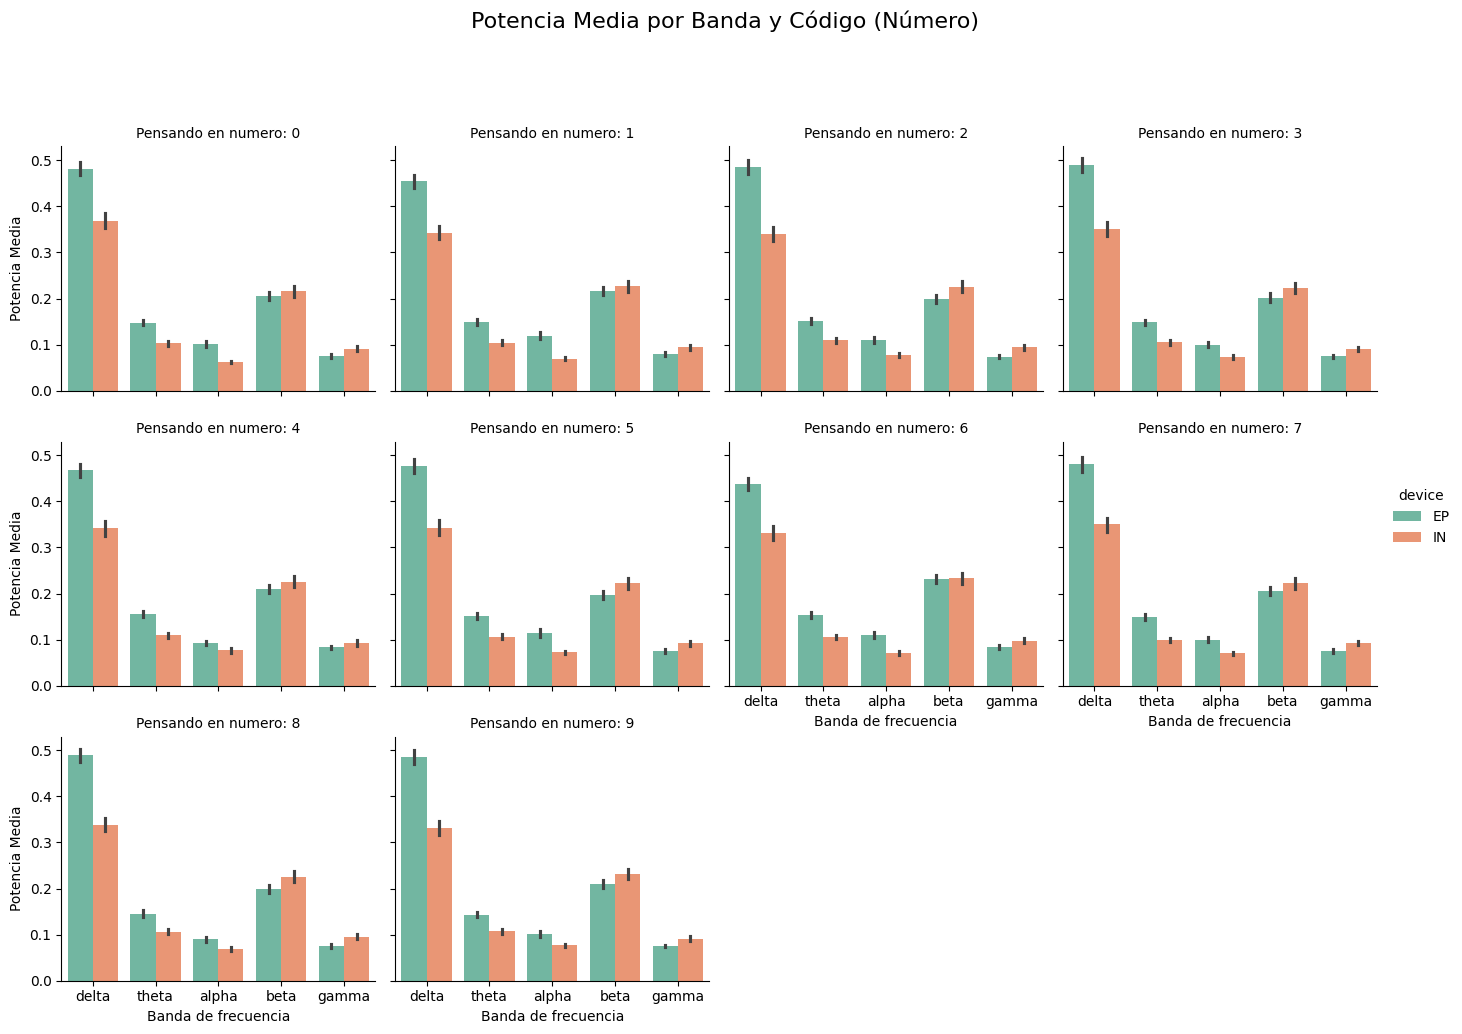

In [16]:
avg_powers_comparison(df_features)

#### Actividad por frecuencia
Siguiendo la linea de lo observado en las representaciones anteriores, no se observan grandes diferencias en la actividad eléctrica generada entre estímulos, incluso diferenciando entre las distintas bandas de frecuencia más habituales en analisis de EEG. En especial cabe destacar que las bandas Theta y Alpha, usualmente asociadas a activación por procesos cognitivos, se mueven en los rangos de 1,5 y 1 de potencia relativa, respectivamente. 

En estás gráficas de potencia relativa podemos observar más claramente cómo la señal detectada por el dispositivo EPOC se corresponde más con la señal de la actividad neuronal generada por el estímulos, con menos ruido interfiriendo en la señal total. Por ello se observan en general mayores potencias relativas para el dispositivo EPOC que para el INSIGHT.


## 6. Conclusiones

Basado en el análisis de este notebook:

1. **Actividad cortical:** Se observa actividad bilateral para los estimulos analizados, presentándose una ligera activación mayor del hemisferio derecho, normalmente más especializado en las tareas de cálculo de magnitudes y con un fuerte componente en la atención espacial, encajando con la tarea realizada de visualización numérica. Además se ha visto una mayor actividad frontotemporal, también asociada a la realización de tareas, mantenimiento de la atención y toma de decisiones. *Es necesario apuntar que no se pueden descartar con este estudio preliminar posibles artefactos o problemas técnicos debidos a los electrodos usados. Sería necesario realziar un estudio más profundo del comportamiento de cada electrodo individual para detectar posibles fallos de contacto o señales aberrantes*
2. **Dispositivo EPOC vs Insight:** Gracias al analisis de potencia absoluta por estimulo se pudo detectar una mayor oscilación de señal en el dispositivo Insight, sugiriendo una mayor fiabilidad en la detección de señales EEG del dispositivo Epoc, aunque también podría deberse al mayor número de electrodos utilizados en este último.
3. **Bandas de frecuencia:** Se observa que las frecuencias más representadas en el analisis de potencia relativa corresponden a las bandas Delta (0.5, 4) y Beta (13, 30), aunque las bandas más interesantes en el analisis de tareas cognitivas como las de este estudio corresponden a la Theta (4, 8) y Alpha (8, 12), asociadas a tareas cognitivas. En estas últimas observamos una buena consistencia en la potencia relativa presentada por cada estímulo y cada dispositivo. Sería interesante analizar estas bandas en más detalle para intentar descubrir patrones que permitan diferenciar con más precisión entre los diferentes estímulos.

**Siguientes pasos sugeridos:** Ampliar el análisis procesando los conjuntos de datos completos (más allá de las 5000 filas) y procesar los datos para entrenar un modelo capaz de distinguir las señales EEG asociadas a cada estímulo.